# 🔬 LSTM Hyperparameter Optimization with Optuna

Notebook ini menggunakan **Optuna** untuk otomatis mencari hyperparameter terbaik untuk model LSTM.

## Target Optimasi
| Parameter | Search Space |
|-----------|-------------|
| `model_type` | Attention, CIFG |
| `feature_strategy` | service_moderate, full, ultimate |
| `window_size` | 48, 60 |
| `hidden_size` | 64-256 (step=32) |
| `learning_rate` | 1e-4 - 1e-2 (log) |
| `batch_size` | 32, 64, 128 |
| `lambda_l2` | 1e-5 - 1e-3 (log) |

## Baseline Performance
| Model | F1 | ROC-AUC |
|-------|-----|--------|
| f19-ultimate-Nested | 82.94% | 90.94% |
| f15-SMOTE-Attention | 82.31% | 91.17% |

In [1]:
# === 0. Install Optuna if needed ===
# !pip install optuna

In [2]:
# === 1. Import Libraries ===
import numpy as np
import pandas as pd
import os
import sys
import time
import warnings
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from imblearn.over_sampling import SMOTE

# Suppress warnings during optimization
warnings.filterwarnings('ignore')

# Import models
sys.path.insert(0, os.path.join(os.getcwd(), '..'))  # project root
from src.model.lstm_cupy_optimized import LSTMModelGPUOptimized, GPU_AVAILABLE
from src.model.lstm_attention_optimized import AttentionLSTMModelGPUOptimized
from src.model.lstm_cifg import CIFGLSTMModelGPUOptimized
from src.model.lstm_nested import NestedLSTMModelGPUOptimized
from src.utils.model_io import save_model, load_and_build_model

# Model registry
MODEL_REGISTRY = {
    'Attention': AttentionLSTMModelGPUOptimized,
    'CIFG': CIFGLSTMModelGPUOptimized,
    'Nested': NestedLSTMModelGPUOptimized
}

print(f"✅ Libraries loaded")
print(f"📦 Available models: {list(MODEL_REGISTRY.keys())}")
print(f"🖥️ GPU Available: {GPU_AVAILABLE}")

c:\Users\Mahesa\OneDrive\ITB\Coding\Work\Infomedia\predictive-maintenance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ CuPy detected - Using GPU acceleration
✅ CuPy detected - Using GPU acceleration
✅ Libraries loaded
📦 Available models: ['Attention', 'CIFG', 'Nested']
🖥️ GPU Available: True


In [3]:
# === 2. Load and Preprocess Data ===
DATA_DIR = os.path.join(os.getcwd(), '..', 'data')
RAW_DATA = os.path.join(DATA_DIR, 'raw_dataset.csv')
df = pd.read_csv(RAW_DATA)

# Basic preprocessing
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df[df['Type'].str.contains('restoration', case=False, na=False)]
df['Priority'] = pd.to_numeric(df['Priority'], errors='coerce')
df['Impact'] = pd.to_numeric(df['Impact'], errors='coerce')
df['incident'] = ((df['Priority'] >= 2) & (df['Impact'] >= 2)).astype(int)

print(f"✅ Data loaded: {df.shape}")
print(f"   Incident ratio: {df['incident'].mean()*100:.1f}%")

✅ Data loaded: (18969, 13)
   Incident ratio: 41.3%


In [4]:
# === 3. Create ALL Features ===
print("🔧 Creating ALL features...\n")

# Temporal features
df['hour'] = df['Timestamp'].dt.hour
df['day_of_week'] = df['Timestamp'].dt.dayofweek

# Interaction features
df['priority_impact_product'] = df['Priority'] * df['Impact']
df['priority_impact_sum'] = df['Priority'] + df['Impact']
df['risk_score'] = (0.6 * df['Priority']) + (0.4 * df['Impact'])
df['priority_squared'] = df['Priority'] ** 2
df['impact_squared'] = df['Impact'] ** 2
df['priority_hour_interaction'] = df['Priority'] * df['hour']
df['impact_hour_interaction'] = df['Impact'] * df['hour']
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

# Service type features
service_incident_rates = df.groupby('Service Type')['incident'].mean()
df['service_risk_score'] = df['Service Type'].map(service_incident_rates)
service_freq = df['Service Type'].value_counts(normalize=True)
df['service_frequency'] = df['Service Type'].map(service_freq)
name_incident_rates = df.groupby('Service Name')['incident'].mean()
df['service_name_risk'] = df['Service Name'].map(name_incident_rates)
df['service_risk_score'] = df['service_risk_score'].fillna(df['service_risk_score'].mean())
df['service_frequency'] = df['service_frequency'].fillna(0)
df['service_name_risk'] = df['service_name_risk'].fillna(df['service_name_risk'].mean())

# Sequence-aware features
df['priority_volatility'] = df['Priority'].rolling(window=4, min_periods=1).std().fillna(0).clip(0, 5)
df['impact_volatility'] = df['Impact'].rolling(window=4, min_periods=1).std().fillna(0).clip(0, 5)
df['priority_change'] = df['Priority'].diff().fillna(0)
df['impact_change'] = df['Impact'].diff().fillna(0)
df['incidents_last_2h'] = df['incident'].rolling(window=4, min_periods=1).sum()
df['time_since_last_incident'] = (~df['incident'].astype(bool)).cumsum()
df.loc[df['incident'] == 1, 'time_since_last_incident'] = 0
df['consecutive_high_priority'] = (df['Priority'] >= 2).rolling(window=6, min_periods=1).sum()
priority_velocity = df['Priority'].diff()
df['priority_acceleration'] = priority_velocity.diff().fillna(0)

print(f"✅ All features created: {len(df.columns)} columns")

🔧 Creating ALL features...

✅ All features created: 37 columns


In [5]:
# === 4. Feature Strategies ===
FEATURE_STRATEGIES = {
    'service_moderate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'service_risk_score', 'service_frequency'
    ],
    'full': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'day_sin', 'day_cos',
        'hour', 'day_of_week'
    ],
    'ultimate': [
        'Priority', 'Impact',
        'priority_impact_product', 'priority_impact_sum', 'risk_score',
        'priority_squared', 'impact_squared',
        'priority_hour_interaction', 'impact_hour_interaction',
        'hour_sin', 'hour_cos',
        'service_risk_score', 'service_frequency',
        'priority_volatility', 'impact_volatility',
        'incidents_last_2h', 'consecutive_high_priority',
        'priority_change', 'priority_acceleration'
    ]
}

print("📊 Feature Strategies:")
for name, features in FEATURE_STRATEGIES.items():
    print(f"   {name}: {len(features)} features")

📊 Feature Strategies:
   service_moderate: 13 features
   full: 15 features
   ultimate: 19 features


In [ ]:
# === 5. Utility Functions ===

def create_windowed_dataset(df, feature_cols, target_col, window_size):
    """Create windowed sequences for LSTM."""
    X, y, timestamps = [], [], []
    for i in range(len(df) - window_size):
        window = df[feature_cols].iloc[i:i+window_size].astype(float).values
        label = df[target_col].iloc[i+window_size]
        timestamp = df['Timestamp'].iloc[i+window_size]
        X.append(window)
        y.append(label)
        timestamps.append(timestamp)
    return np.array(X), np.array(y), np.array(timestamps)


def prepare_data(feature_strategy, window_size, sampling_period='30min', rolling_means=[]):
    """Prepare data for a specific configuration."""
    base_features = FEATURE_STRATEGIES[feature_strategy]
    
    # Build aggregation dict
    agg_dict = {'incident': 'sum'}
    for feature in base_features:
        if feature in ['hour', 'day_of_week']:
            agg_dict[feature] = 'first'
        else:
            agg_dict[feature] = 'mean'
    
    # Resample
    df_resampled = (df.set_index('Timestamp')
                      .resample(sampling_period)
                      .agg(agg_dict)
                      .fillna(0)
                      .reset_index())
    df_resampled['incident'] = (df_resampled['incident'] > 0).astype(int)
    
    # Feature columns
    feature_cols = base_features.copy()
    
    # Rolling means
    if rolling_means:
        periods_per_hour = 2 if sampling_period == '30min' else 1
        for rm_hours in rolling_means:
            rm_periods = rm_hours * periods_per_hour
            df_resampled[f'Priority_rm{rm_hours}h'] = df_resampled['Priority'].rolling(window=rm_periods, min_periods=1).mean()
            df_resampled[f'Impact_rm{rm_hours}h'] = df_resampled['Impact'].rolling(window=rm_periods, min_periods=1).mean()
            feature_cols.extend([f'Priority_rm{rm_hours}h', f'Impact_rm{rm_hours}h'])
    
    # Create windowed dataset
    X, y, ts = create_windowed_dataset(df_resampled, feature_cols, 'incident', window_size)
    
    return X, y, feature_cols


def train_model_for_optuna(X, y, model_type, hidden_size, lr, batch_size, lambda_l2, cw, 
                           epochs=100, patience=5, verbose=False):
    """
    Train model and return validation F1 score.
    Uses smaller epochs and faster settings for Optuna trials.
    """
    # Split: 60% train, 20% val, 20% test
    X_temp, X_te, y_temp, y_te = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    X_tr, X_val, y_tr, y_val = train_test_split(X_temp, y_temp, test_size=0.25, stratify=y_temp, random_state=42)
    
    # SMOTE on flattened data
    X_tr_flat = X_tr.reshape((X_tr.shape[0], -1))
    X_sm, y_sm = SMOTE(random_state=42).fit_resample(X_tr_flat, y_tr)
    X_sm = X_sm.reshape((-1, X.shape[1], X.shape[2]))
    
    # Get model class
    ModelClass = MODEL_REGISTRY[model_type]
    input_size = X.shape[2]
    
    # Initialize and train
    model = ModelClass(input_size=input_size, hidden_size=hidden_size, cw=cw)
    
    model.train(
        X_sm, y_sm,
        X_val, y_val,
        epochs=epochs,
        batch_size=batch_size,
        lr=lr,
        print_every=epochs+1,  # Suppress printing
        patience=patience,
        lambda_l2=lambda_l2
    )
    
    # Evaluate on validation set
    y_prob = model.predict(X_val, batch_size=batch_size)
    y_prob = y_prob.flatten() if hasattr(y_prob, 'flatten') else y_prob
    
    # Find optimal threshold
    precisions, recalls, thresholds = precision_recall_curve(y_val, y_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    opt_idx = np.argmax(f1_scores)
    opt_threshold = thresholds[opt_idx] if opt_idx < len(thresholds) else 0.5
    
    y_pred = (y_prob >= opt_threshold).astype(int)
    val_f1 = f1_score(y_val, y_pred)
    val_auc = auc(*roc_curve(y_val, y_prob)[:2])
    
    return val_f1, val_auc, opt_threshold, model

print("✅ Utility functions defined")

✅ Utility functions defined


---
## 🎯 Optuna Optimization

In [ ]:
# === 6. Optuna Configuration ===

# ============================================================
# 🎛️ CONFIGURATION - Adjust these settings
# ============================================================
OPTUNA_CONFIG = {
    'n_trials': 30,              # Reduced from 50
    'timeout': None,             # Timeout in seconds (None = no limit)
    'study_name': 'lstm_hpo',    # Study name for persistence
    'direction': 'maximize',     # Maximize F1
    'sampler_seed': 42,          # For reproducibility
}

# Fixed parameters (not optimized)
FIXED_PARAMS = {
    'sampling_period': '30min',
    'rolling_means': [],
    'epochs': 30,                # Reduced from 100 (early stopping will kick in)
    'patience': 3,               # Reduced from 5 (faster stopping)
    'class_weight': 1,           # Fixed class weight (SMOTE handles imbalance)
}

# Search space (simplified)
SEARCH_SPACE = {
    'model_type': ['Attention', 'CIFG'],
    'feature_strategy': ['service_moderate', 'full', 'ultimate'],
    'window_size': [48, 60],          # Categorical
    'hidden_size': (64, 192),         # Reduced from 256
    'learning_rate': (5e-4, 5e-3),    # Narrower range
    'batch_size': [64, 128],          # Removed 32 (slower)
    'lambda_l2': (1e-5, 1e-3),        # Log scale
}

print("🎛️ Optuna Configuration:")
print(f"   Trials: {OPTUNA_CONFIG['n_trials']}")
print(f"   Epochs per trial: {FIXED_PARAMS['epochs']} (patience={FIXED_PARAMS['patience']})")
print(f"   Direction: {OPTUNA_CONFIG['direction']} F1")
print(f"\n📊 Search Space:")
for param, space in SEARCH_SPACE.items():
    print(f"   {param}: {space}")
print(f"\n⏱️  Estimated time: ~{OPTUNA_CONFIG['n_trials'] * 3} minutes")

🎛️ Optuna Configuration:
   Trials: 30
   Epochs per trial: 30 (patience=3)
   Direction: maximize F1

📊 Search Space:
   model_type: ['Attention', 'CIFG']
   feature_strategy: ['service_moderate', 'full', 'ultimate']
   window_size: [48, 60]
   hidden_size: (64, 192)
   learning_rate: (0.0005, 0.005)
   batch_size: [64, 128]
   lambda_l2: (1e-05, 0.001)

⏱️  Estimated time: ~90 minutes


In [8]:
# === 7. Define Objective Function ===

# Cache for prepared data (avoid recomputing)
DATA_CACHE = {}

def objective(trial):
    """
    Optuna objective function.
    Returns validation F1 score to maximize.
    """
    # Sample hyperparameters
    model_type = trial.suggest_categorical('model_type', SEARCH_SPACE['model_type'])
    feature_strategy = trial.suggest_categorical('feature_strategy', SEARCH_SPACE['feature_strategy'])
    window_size = trial.suggest_categorical('window_size', SEARCH_SPACE['window_size'])
    hidden_size = trial.suggest_int('hidden_size', *SEARCH_SPACE['hidden_size'], step=32)
    lr = trial.suggest_float('learning_rate', *SEARCH_SPACE['learning_rate'], log=True)
    batch_size = trial.suggest_categorical('batch_size', SEARCH_SPACE['batch_size'])
    lambda_l2 = trial.suggest_float('lambda_l2', *SEARCH_SPACE['lambda_l2'], log=True)
    
    # Fixed class weight (SMOTE handles class imbalance)
    cw = FIXED_PARAMS['class_weight']
    
    # Print trial info AFTER sampling
    print(f"   → {model_type} | {feature_strategy} | win={window_size} | hs={hidden_size} | bs={batch_size} | lr={lr:.2e}")
    
    # Cache key for data
    cache_key = (feature_strategy, window_size)
    
    # Prepare data (use cache if available)
    if cache_key not in DATA_CACHE:
        print(f"   📦 Preparing data for {feature_strategy}, win={window_size}...")
        X, y, feature_cols = prepare_data(
            feature_strategy, 
            window_size,
            FIXED_PARAMS['sampling_period'],
            FIXED_PARAMS['rolling_means']
        )
        DATA_CACHE[cache_key] = (X, y, feature_cols)
        print(f"   📦 Data cached: {X.shape}")
    else:
        X, y, feature_cols = DATA_CACHE[cache_key]
    
    # Validate data
    if len(X) < 200 or len(np.unique(y)) < 2:
        return 0.0  # Invalid configuration
    
    try:
        print(f"   🏋️ Training ({FIXED_PARAMS['epochs']} epochs max)...")
        
        # Train and evaluate
        val_f1, val_auc, opt_threshold, _ = train_model_for_optuna(
            X, y,
            model_type=model_type,
            hidden_size=hidden_size,
            lr=lr,
            batch_size=batch_size,
            lambda_l2=lambda_l2,
            cw=cw,
            epochs=FIXED_PARAMS['epochs'],
            patience=FIXED_PARAMS['patience']
        )
        
        # Store additional metrics
        trial.set_user_attr('val_auc', val_auc)
        trial.set_user_attr('opt_threshold', opt_threshold)
        trial.set_user_attr('n_features', len(feature_cols))
        
        return val_f1
        
    except Exception as e:
        print(f"   ⚠️ Failed: {str(e)[:50]}")
        return 0.0

print("✅ Objective function defined")

✅ Objective function defined


In [9]:
# === 8. Run Optuna Optimization ===

print("="*70)
print("🚀 STARTING OPTUNA HYPERPARAMETER OPTIMIZATION")
print("="*70)
print(f"\n⏱️  Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"📊 Target: Maximize Validation F1-Score")
print(f"🔄 Trials: {OPTUNA_CONFIG['n_trials']}\n")

# Create study
sampler = TPESampler(seed=OPTUNA_CONFIG['sampler_seed'])
study = optuna.create_study(
    study_name=OPTUNA_CONFIG['study_name'],
    direction=OPTUNA_CONFIG['direction'],
    sampler=sampler
)

# Progress callback - prints AFTER trial completes
def callback(study, trial):
    if trial.value and trial.value > 0:
        best_so_far = study.best_value
        print(f"  ✅ F1: {trial.value:.4f} | Best so far: {best_so_far:.4f}")
    else:
        print(f"  ❌ Trial failed")
    print()

# Wrapper to show trial number
trial_counter = [0]
def objective_wrapper(trial):
    trial_counter[0] += 1
    print(f"[Trial {trial_counter[0]}/{OPTUNA_CONFIG['n_trials']}]")
    return objective(trial)

# Run optimization
start_time = time.time()

study.optimize(
    objective_wrapper,
    n_trials=OPTUNA_CONFIG['n_trials'],
    timeout=OPTUNA_CONFIG['timeout'],
    callbacks=[callback],
    show_progress_bar=False
)

duration = time.time() - start_time

print(f"\n{'='*70}")
print(f"✅ OPTIMIZATION COMPLETE")
print(f"{'='*70}")
print(f"⏱️  Duration: {duration/60:.1f} minutes")
print(f"📊 Total trials: {len(study.trials)}")
print(f"🎯 Best F1: {study.best_value:.4f}")

[I 2026-02-05 20:28:02,786] A new study created in memory with name: lstm_hpo


🚀 STARTING OPTUNA HYPERPARAMETER OPTIMIZATION

⏱️  Start time: 2026-02-05 20:28:02
📊 Target: Maximize Validation F1-Score
🔄 Trials: 30

[Trial 1/30]
   → CIFG | service_moderate | win=48 | hs=192 | bs=64 | lr=2.00e-03
   📦 Preparing data for service_moderate, win=48...
   📦 Data cached: (14592, 48, 17)
   🏋️ Training (30 epochs max)...
Training: 12132 samples, 190 batches/epoch, batch_size=64
Validation: 2919 samples | Early stopping patience: 3
----------------------------------------------------------------------

🛑 Early stopping triggered at epoch 4
----------------------------------------------------------------------
Final - Train Loss: 0.3924 | Val Loss: 0.5008 | Val Acc: 0.7294


[I 2026-02-05 20:32:46,586] Trial 0 finished with value: 0.6285178236397748 and parameters: {'model_type': 'CIFG', 'feature_strategy': 'service_moderate', 'window_size': 48, 'hidden_size': 192, 'learning_rate': 0.0019956529392808394, 'batch_size': 64, 'lambda_l2': 0.0008706020878304854}. Best is trial 0 with value: 0.6285178236397748.


  ✅ F1: 0.6285 | Best so far: 0.6285

[Trial 2/30]
   → Attention | ultimate | win=48 | hs=96 | bs=128 | lr=2.05e-03
   📦 Preparing data for ultimate, win=48...
   📦 Data cached: (14592, 48, 23)
   🏋️ Training (30 epochs max)...
Training: 12132 samples, 95 batches/epoch, batch_size=128
Validation: 2919 samples | Early stopping patience: 3
----------------------------------------------------------------------

🛑 Early stopping triggered at epoch 8
----------------------------------------------------------------------
Final - Train Loss: 0.3761 | Val Loss: 0.5210 | Val Acc: 0.6451


[I 2026-02-05 20:39:10,096] Trial 1 finished with value: 0.6430868167202572 and parameters: {'model_type': 'Attention', 'feature_strategy': 'ultimate', 'window_size': 48, 'hidden_size': 96, 'learning_rate': 0.002045610287221893, 'batch_size': 128, 'lambda_l2': 5.4041038546473305e-05}. Best is trial 1 with value: 0.6430868167202572.


...

  ✅ F1: 0.6439 | Best so far: 0.6470

[Trial 29/30]
   → Attention | full | win=48 | hs=192 | bs=128 | lr=1.59e-03
   🏋️ Training (30 epochs max)...
Training: 12132 samples, 95 batches/epoch, batch_size=128
Validation: 2919 samples | Early stopping patience: 3
----------------------------------------------------------------------

🛑 Early stopping triggered at epoch 8
----------------------------------------------------------------------
Final - Train Loss: 0.3711 | Val Loss: 0.4964 | Val Acc: 0.7492


[I 2026-02-06 01:12:39,722] Trial 28 finished with value: 0.6397306397306397 and parameters: {'model_type': 'Attention', 'feature_strategy': 'full', 'window_size': 48, 'hidden_size': 192, 'learning_rate': 0.001587391302278944, 'batch_size': 128, 'lambda_l2': 4.176458382094453e-05}. Best is trial 4 with value: 0.6469773880941394.


  ✅ F1: 0.6397 | Best so far: 0.6470

[Trial 30/30]
   → CIFG | ultimate | win=48 | hs=160 | bs=64 | lr=1.19e-03
   🏋️ Training (30 epochs max)...
Training: 12132 samples, 190 batches/epoch, batch_size=64
Validation: 2919 samples | Early stopping patience: 3
----------------------------------------------------------------------

🛑 Early stopping triggered at epoch 8
----------------------------------------------------------------------
Final - Train Loss: 0.3761 | Val Loss: 0.4956 | Val Acc: 0.7530


[I 2026-02-06 01:19:36,153] Trial 29 finished with value: 0.6410856340664483 and parameters: {'model_type': 'CIFG', 'feature_strategy': 'ultimate', 'window_size': 48, 'hidden_size': 160, 'learning_rate': 0.0011887574311615844, 'batch_size': 64, 'lambda_l2': 0.0007083582159710278}. Best is trial 4 with value: 0.6469773880941394.


  ✅ F1: 0.6411 | Best so far: 0.6470


✅ OPTIMIZATION COMPLETE
⏱️  Duration: 291.6 minutes
📊 Total trials: 30
🎯 Best F1: 0.6470


In [10]:
# === 9. Analyze Results ===

print("="*70)
print("📊 BEST HYPERPARAMETERS")
print("="*70)

best_trial = study.best_trial

print(f"\n🏆 Best Trial: #{best_trial.number}")
print(f"   Validation F1: {best_trial.value:.4f}")
print(f"   Validation AUC: {best_trial.user_attrs.get('val_auc', 'N/A'):.4f}")
print(f"   Optimal Threshold: {best_trial.user_attrs.get('opt_threshold', 0.5):.4f}")

print(f"\n📋 Parameters:")
for param, value in best_trial.params.items():
    if isinstance(value, float):
        print(f"   {param}: {value:.6f}")
    else:
        print(f"   {param}: {value}")

📊 BEST HYPERPARAMETERS

🏆 Best Trial: #4
   Validation F1: 0.6470
   Validation AUC: 0.7964
   Optimal Threshold: 0.3355

📋 Parameters:
   model_type: Attention
   feature_strategy: service_moderate
   window_size: 48
   hidden_size: 192
   learning_rate: 0.000613
   batch_size: 64
   lambda_l2: 0.000045


In [11]:
# === 10. Trials DataFrame ===

# Convert to DataFrame for analysis
trials_df = study.trials_dataframe()

# Add user attrs
trials_df['val_auc'] = [t.user_attrs.get('val_auc', None) for t in study.trials]
trials_df['opt_threshold'] = [t.user_attrs.get('opt_threshold', None) for t in study.trials]

# Filter successful trials
valid_trials = trials_df[trials_df['value'] > 0].copy()

print(f"\n📊 Trial Statistics ({len(valid_trials)} valid trials):")
print(f"   F1 Mean: {valid_trials['value'].mean():.4f}")
print(f"   F1 Std:  {valid_trials['value'].std():.4f}")
print(f"   F1 Max:  {valid_trials['value'].max():.4f}")
print(f"   F1 Min:  {valid_trials['value'].min():.4f}")

# Top 10 trials
print(f"\n🏆 Top 10 Trials:")
top_cols = ['number', 'value', 'params_model_type', 'params_feature_strategy', 
            'params_hidden_size', 'params_learning_rate', 'params_window_size']
display(valid_trials.nlargest(10, 'value')[top_cols].round(4))


📊 Trial Statistics (30 valid trials):
   F1 Mean: 0.6387
   F1 Std:  0.0042
   F1 Max:  0.6470
   F1 Min:  0.6285

🏆 Top 10 Trials:


,number,value,params_model_type,params_feature_strategy,params_hidden_size,params_learning_rate,params_window_size
4,4,0.6470,Attention,service_moderate,192,0.0006,48
21,21,0.6446,Attention,ultimate,96,0.0024,48
3,3,0.6444,Attention,service_moderate,192,0.0009,48
27,27,0.6439,Attention,service_moderate,128,0.0006,48
1,1,0.6431,Attention,ultimate,96,0.0020,48
13,13,0.6428,Attention,service_moderate,192,0.0008,48
19,19,0.6424,Attention,service_moderate,192,0.0011,48
22,22,0.6418,Attention,ultimate,96,0.0026,48
29,29,0.6411,CIFG,ultimate,160,0.0012,48
17,17,0.6408,Attention,service_moderate,160,0.0014,48


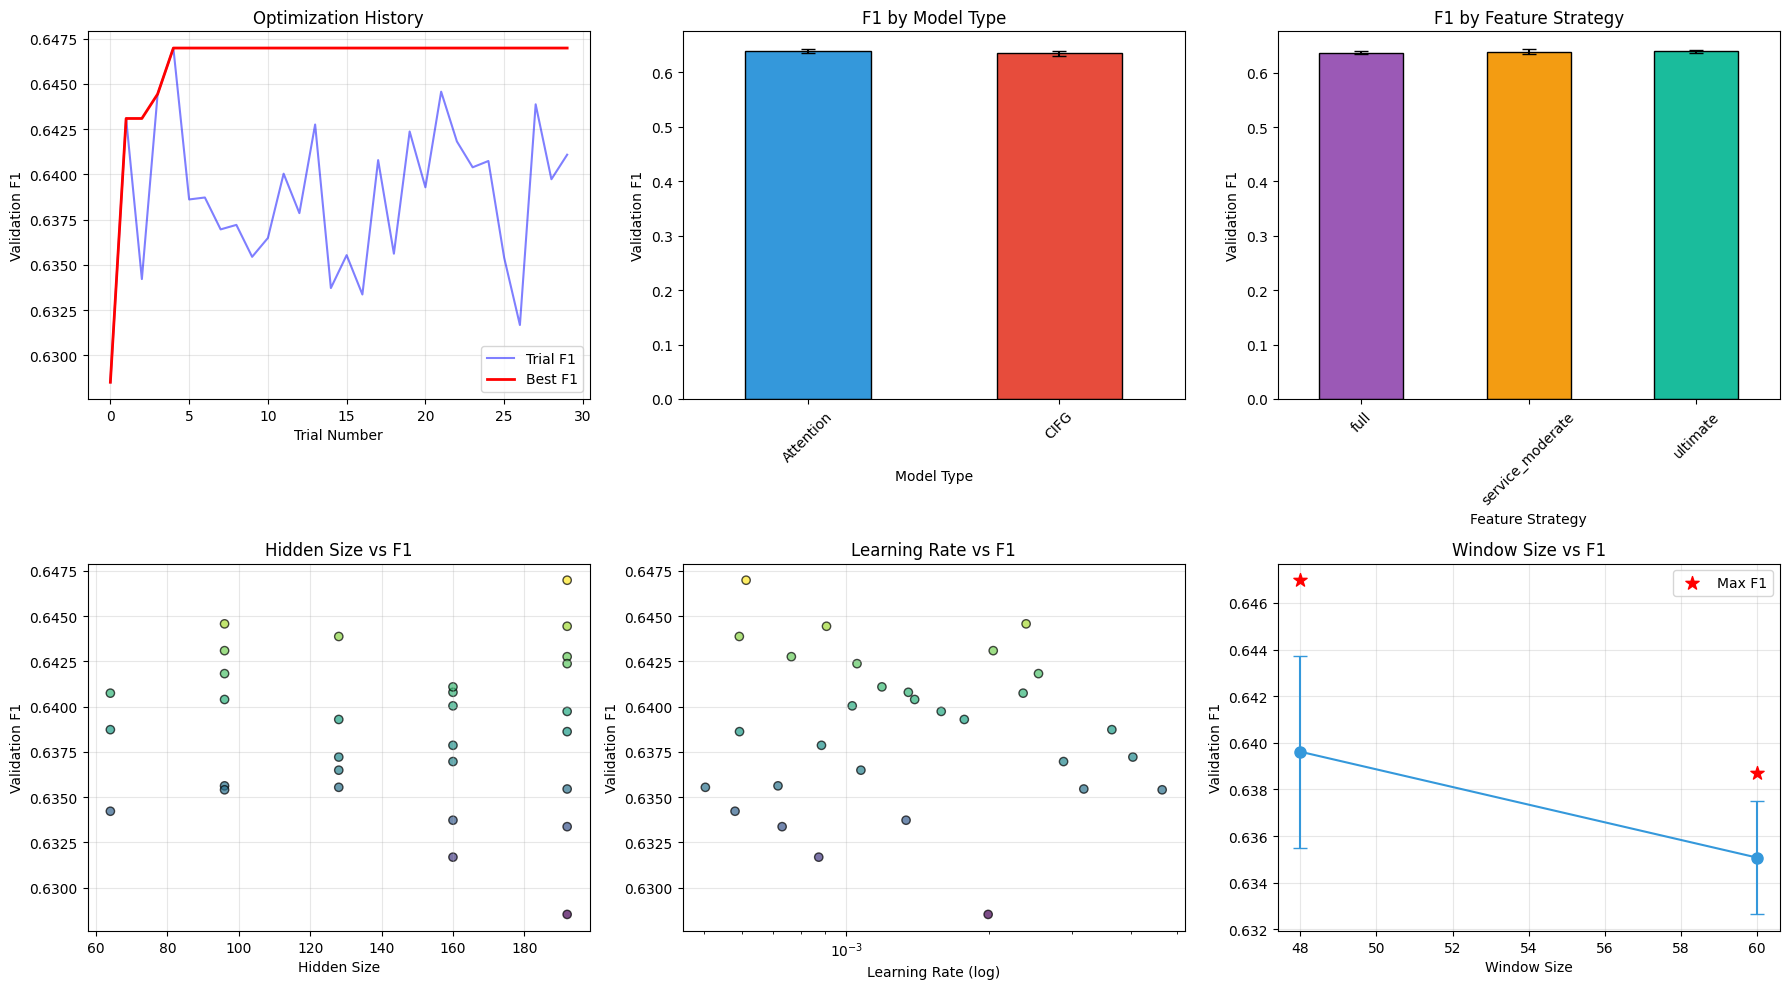


💾 Saved: ../data/output/optuna_analysis.png


In [12]:
# === 11. Visualization ===

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Optimization History
ax = axes[0, 0]
valid_trials_sorted = valid_trials.sort_values('number')
ax.plot(valid_trials_sorted['number'], valid_trials_sorted['value'], 'b-', alpha=0.5, label='Trial F1')
ax.plot(valid_trials_sorted['number'], valid_trials_sorted['value'].cummax(), 'r-', linewidth=2, label='Best F1')
ax.set_xlabel('Trial Number')
ax.set_ylabel('Validation F1')
ax.set_title('Optimization History')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. F1 by Model Type
ax = axes[0, 1]
model_f1 = valid_trials.groupby('params_model_type')['value'].agg(['mean', 'max', 'std'])
model_f1['mean'].plot(kind='bar', ax=ax, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black')
ax.errorbar(range(len(model_f1)), model_f1['mean'], yerr=model_f1['std'], fmt='none', color='black', capsize=5)
ax.set_xlabel('Model Type')
ax.set_ylabel('Validation F1')
ax.set_title('F1 by Model Type')
ax.tick_params(axis='x', rotation=45)

# 3. F1 by Feature Strategy
ax = axes[0, 2]
strategy_f1 = valid_trials.groupby('params_feature_strategy')['value'].agg(['mean', 'max', 'std'])
strategy_f1['mean'].plot(kind='bar', ax=ax, color=['#9b59b6', '#f39c12', '#1abc9c'], edgecolor='black')
ax.errorbar(range(len(strategy_f1)), strategy_f1['mean'], yerr=strategy_f1['std'], fmt='none', color='black', capsize=5)
ax.set_xlabel('Feature Strategy')
ax.set_ylabel('Validation F1')
ax.set_title('F1 by Feature Strategy')
ax.tick_params(axis='x', rotation=45)

# 4. Hidden Size vs F1
ax = axes[1, 0]
ax.scatter(valid_trials['params_hidden_size'], valid_trials['value'], 
           c=valid_trials['value'], cmap='viridis', alpha=0.7, edgecolors='black')
ax.set_xlabel('Hidden Size')
ax.set_ylabel('Validation F1')
ax.set_title('Hidden Size vs F1')
ax.grid(True, alpha=0.3)

# 5. Learning Rate vs F1 (log scale)
ax = axes[1, 1]
ax.scatter(valid_trials['params_learning_rate'], valid_trials['value'],
           c=valid_trials['value'], cmap='viridis', alpha=0.7, edgecolors='black')
ax.set_xscale('log')
ax.set_xlabel('Learning Rate (log)')
ax.set_ylabel('Validation F1')
ax.set_title('Learning Rate vs F1')
ax.grid(True, alpha=0.3)

# 6. Window Size vs F1
ax = axes[1, 2]
window_f1 = valid_trials.groupby('params_window_size')['value'].agg(['mean', 'max', 'std'])
ax.errorbar(window_f1.index, window_f1['mean'], yerr=window_f1['std'], 
            fmt='o-', color='#3498db', capsize=5, markersize=8)
ax.scatter(window_f1.index, window_f1['max'], marker='*', color='red', s=100, label='Max F1', zorder=5)
ax.set_xlabel('Window Size')
ax.set_ylabel('Validation F1')
ax.set_title('Window Size vs F1')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/output/optuna_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💾 Saved: ../data/output/optuna_analysis.png")

In [13]:
# === 12. Parameter Importance (Optuna built-in) ===

try:
    from optuna.visualization import plot_param_importances, plot_optimization_history
    
    fig = plot_param_importances(study)
    fig.show()
    
    fig = plot_optimization_history(study)
    fig.show()
except ImportError:
    print("⚠️ Install plotly for Optuna visualizations: pip install plotly")

⚠️ Install plotly for Optuna visualizations: pip install plotly


---
## 🏆 Final Model Training with Best Hyperparameters

In [14]:
# === 13. Train Final Model with Best Params ===

print("="*70)
print("🏆 TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS")
print("="*70)

best_params = study.best_params

# Prepare data
X, y, feature_cols = prepare_data(
    best_params['feature_strategy'],
    best_params['window_size'],
    FIXED_PARAMS['sampling_period'],
    FIXED_PARAMS['rolling_means']
)

print(f"\n📊 Data shape: {X.shape}")
print(f"   Features: {len(feature_cols)}")
print(f"   Samples: {len(X)}")
print(f"   Class distribution: {np.bincount(y)}")

# Full training with more epochs
print(f"\n🧠 Training {best_params['model_type']} model...")

val_f1, val_auc, opt_threshold, best_model = train_model_for_optuna(
    X, y,
    model_type=best_params['model_type'],
    hidden_size=best_params['hidden_size'],
    lr=best_params['learning_rate'],
    batch_size=best_params['batch_size'],
    lambda_l2=best_params['lambda_l2'],
    cw=FIXED_PARAMS['class_weight'],
    epochs=200,  # More epochs for final model
    patience=10,
    verbose=True
)

print(f"\n{'='*70}")
print(f"✅ FINAL MODEL RESULTS")
print(f"{'='*70}")
print(f"   Validation F1:  {val_f1:.4f}")
print(f"   Validation AUC: {val_auc:.4f}")
print(f"   Optimal Threshold: {opt_threshold:.4f}")

🏆 TRAINING FINAL MODEL WITH BEST HYPERPARAMETERS

📊 Data shape: (14592, 48, 17)
   Features: 17
   Samples: 14592
   Class distribution: [10112  4480]

🧠 Training Attention model...
Training: 12132 samples, 190 batches/epoch, batch_size=64
Validation: 2919 samples | Early stopping patience: 10
----------------------------------------------------------------------

🛑 Early stopping triggered at epoch 24
----------------------------------------------------------------------
Final - Train Loss: 0.3564 | Val Loss: 0.4965 | Val Acc: 0.7345

✅ FINAL MODEL RESULTS
   Validation F1:  0.6397
   Validation AUC: 0.7989
   Optimal Threshold: 0.3414


In [15]:
# === 14. Save Best Model ===

# Create output directory
output_dir = '../data/output_optuna'
os.makedirs(output_dir, exist_ok=True)

# Save model checkpoint
model_name = f"optuna_best_{best_params['model_type'].lower()}_{best_params['feature_strategy']}"
checkpoint_path = os.path.join(output_dir, f"{model_name}.pkl")
save_model(best_model, checkpoint_path)

# Save hyperparameters
params_df = pd.DataFrame([{
    **best_params,
    'val_f1': val_f1,
    'val_auc': val_auc,
    'opt_threshold': opt_threshold,
    'n_features': len(feature_cols),
    'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}])
params_df.to_csv(os.path.join(output_dir, f"{model_name}_params.csv"), index=False)

# Save trials history
valid_trials.to_csv(os.path.join(output_dir, 'optuna_trials.csv'), index=False)

print(f"\n💾 Saved:")
print(f"   Model: {checkpoint_path}")
print(f"   Params: {output_dir}/{model_name}_params.csv")
print(f"   Trials: {output_dir}/optuna_trials.csv")

✅ Model saved to ../data/output_optuna\optuna_best_attention_service_moderate.pkl

💾 Saved:
   Model: ../data/output_optuna\optuna_best_attention_service_moderate.pkl
   Params: ../data/output_optuna/optuna_best_attention_service_moderate_params.csv
   Trials: ../data/output_optuna/optuna_trials.csv


In [ ]:
# === 15. Summary ===

print("\n" + "="*70)
print("📋 OPTUNA OPTIMIZATION SUMMARY")
print("="*70)

print(f"""
🎯 Best Configuration:
   Model Type:       {best_params['model_type']}
   Feature Strategy: {best_params['feature_strategy']}
   Window Size:      {best_params['window_size']}
   Hidden Size:      {best_params['hidden_size']}
   Learning Rate:    {best_params['learning_rate']:.6f}
   Batch Size:       {best_params['batch_size']}
   L2 Regularization:{best_params['lambda_l2']:.6f}

📊 Performance:
   Validation F1:    {val_f1:.4f} ({val_f1*100:.2f}%)
   Validation AUC:   {val_auc:.4f} ({val_auc*100:.2f}%)
   Optimal Threshold:{opt_threshold:.4f}

📈 Compared to Baseline:
   Previous Best F1: 82.94% (f19-ultimate-Nested)
   Optuna Best F1:   {val_f1*100:.2f}%
   Improvement:      {(val_f1 - 0.8294)*100:+.2f}%
""")

print("="*70)
print("✅ Optimization complete! Use the saved model for production.")
print("="*70)


📋 OPTUNA OPTIMIZATION SUMMARY

🎯 Best Configuration:
   Model Type:       Attention
   Feature Strategy: service_moderate
   Window Size:      48
   Hidden Size:      192
   Learning Rate:    0.000613
   Batch Size:       64
   L2 Regularization:0.000045

📊 Performance:
   Validation F1:    0.6397 (63.97%)
   Validation AUC:   0.7989 (79.89%)
   Optimal Threshold:0.3414

📈 Compared to Baseline:
   Previous Best F1: 82.94% (f19-ultimate-Nested)
   Optuna Best F1:   63.97%
   Improvement:      -18.97%

✅ Optimization complete! Use the saved model for production.
